API 설정

In [1]:
from google.colab import userdata
import os

os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"]      = userdata.get("KAGGLE_KEY")

!pip install -q kaggle
print("✅ Kaggle API 설정 완료")

✅ Kaggle API 설정 완료


In [2]:
# 다운로드
!kaggle datasets download -d fanconic/skin-cancer-malignant-vs-benign --path ./data

# 압축 해제
import zipfile
with zipfile.ZipFile("./data/skin-cancer-malignant-vs-benign.zip", "r") as z:
    z.extractall("./data")
print("✅ 완료")

Dataset URL: https://www.kaggle.com/datasets/fanconic/skin-cancer-malignant-vs-benign
License(s): unknown
skin-cancer-malignant-vs-benign.zip: Skipping, found more recently modified local copy (use --force to force download)
✅ 완료


In [3]:
import os

for root, dirs, files in os.walk("./data"):
    level = root.replace("./data", "").count(os.sep)
    if level > 2:
        continue
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/  ({len(files)}개)")

data/  (1개)
  data/  (0개)
    test/  (0개)
    train/  (0개)
  test/  (0개)
    malignant/  (300개)
    benign/  (360개)
  train/  (0개)
    malignant/  (1197개)
    benign/  (1440개)


In [4]:
!pip install -q timm

import torch
import torchvision
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ 사용 장치: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

✅ 사용 장치: cuda
   GPU: Tesla T4


EDA

In [5]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

train_dir = "./data/train"
test_dir  = "./data/test"

# 클래스별 데이터 수 확인
train_benign    = len(os.listdir(f"{train_dir}/benign"))
train_malignant = len(os.listdir(f"{train_dir}/malignant"))
test_benign     = len(os.listdir(f"{test_dir}/benign"))
test_malignant  = len(os.listdir(f"{test_dir}/malignant"))

print("📊 데이터셋 현황")
print(f"  [Train] benign: {train_benign}개 | malignant: {train_malignant}개 | 합계: {train_benign+train_malignant}개")
print(f"  [Test]  benign: {test_benign}개  | malignant: {test_malignant}개  | 합계: {test_benign+test_malignant}개")

📊 데이터셋 현황
  [Train] benign: 1440개 | malignant: 1197개 | 합계: 2637개
  [Test]  benign: 360개  | malignant: 300개  | 합계: 660개


/tmp/ipykernel_24176/920675801.py:27: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24176/920675801.py:27: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24176/920675801.py:27: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24176/920675801.py:27: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24176/920675801.py:27: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24176/920675801.py:27: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24176/920675801.py:27: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layou

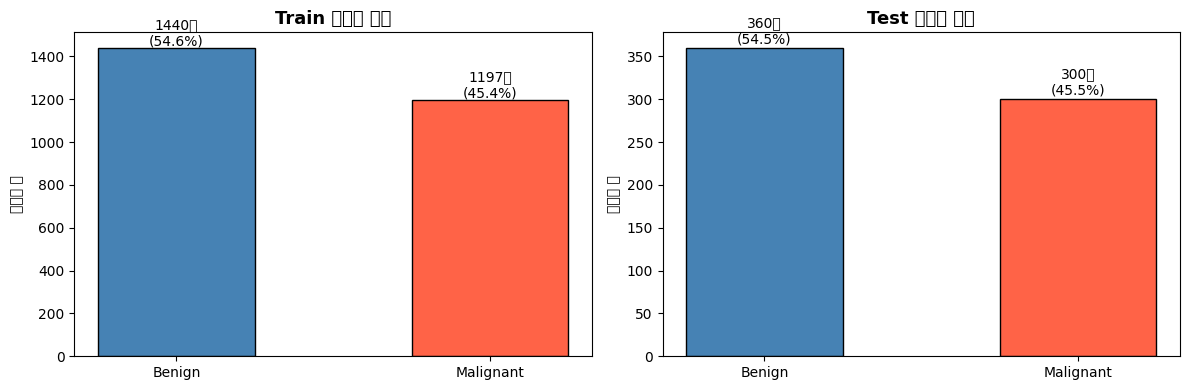

In [6]:
# 클래스 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

labels  = ["Benign", "Malignant"]
train_counts = [train_benign, train_malignant]
test_counts  = [test_benign,  test_malignant]
colors = ["steelblue", "tomato"]

# Train 분포
bars = axes[0].bar(labels, train_counts, color=colors, edgecolor="black", width=0.5)
axes[0].set_title("Train 클래스 분포", fontsize=13, fontweight="bold")
axes[0].set_ylabel("이미지 수")
for bar, val in zip(bars, train_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 10,
                 f"{val}개\n({val/(train_benign+train_malignant)*100:.1f}%)",
                 ha="center", fontsize=10)

# Test 분포
bars = axes[1].bar(labels, test_counts, color=colors, edgecolor="black", width=0.5)
axes[1].set_title("Test 클래스 분포", fontsize=13, fontweight="bold")
axes[1].set_ylabel("이미지 수")
for bar, val in zip(bars, test_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 5,
                 f"{val}개\n({val/(test_benign+test_malignant)*100:.1f}%)",
                 ha="center", fontsize=10)

plt.tight_layout()
plt.show()

/tmp/ipykernel_24176/1441067709.py:22: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24176/1441067709.py:22: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24176/1441067709.py:22: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24176/1441067709.py:22: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24176/1441067709.py:22: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24176/1441067709.py:22: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24176/1441067709.py:22: UserWarning: Glyph 50500 (\N{HANGUL SYLLABLE A}) missing from font(s) DejaVu Sans.
  plt.tight

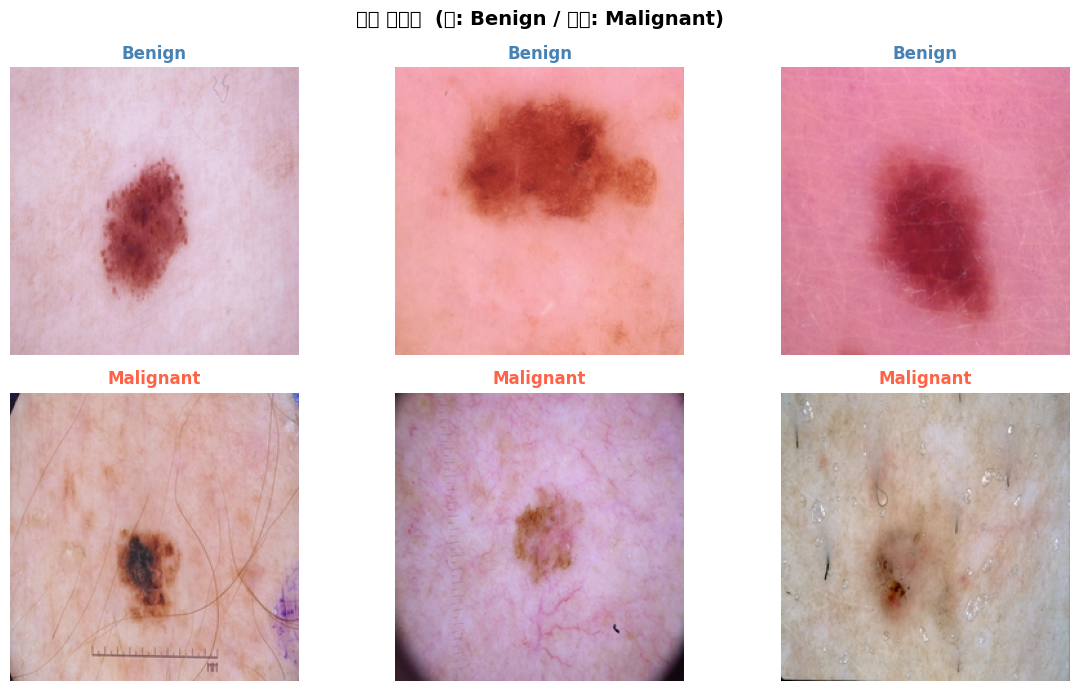

In [7]:
# 샘플 이미지 시각화 (benign 3장 / malignant 3장)
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
fig.suptitle("샘플 이미지  (위: Benign / 아래: Malignant)", fontsize=14, fontweight="bold")

for i in range(3):
    # Benign
    b_file = os.listdir(f"{train_dir}/benign")[i]
    b_img  = cv2.imread(f"{train_dir}/benign/{b_file}")
    b_img  = cv2.cvtColor(b_img, cv2.COLOR_BGR2RGB)
    axes[0][i].imshow(b_img)
    axes[0][i].set_title(f"Benign", color="steelblue", fontweight="bold")
    axes[0][i].axis("off")

    # Malignant
    m_file = os.listdir(f"{train_dir}/malignant")[i]
    m_img  = cv2.imread(f"{train_dir}/malignant/{m_file}")
    m_img  = cv2.cvtColor(m_img, cv2.COLOR_BGR2RGB)
    axes[1][i].imshow(m_img)
    axes[1][i].set_title(f"Malignant", color="tomato", fontweight="bold")
    axes[1][i].axis("off")

plt.tight_layout()
plt.show()

In [8]:
# 이미지 크기 확인 (샘플 10장)
print("📐 이미지 크기 샘플 확인")
for fname in os.listdir(f"{train_dir}/benign")[:5]:
    img = cv2.imread(f"{train_dir}/benign/{fname}")
    print(f"  benign    - {fname}: {img.shape}")

for fname in os.listdir(f"{train_dir}/malignant")[:5]:
    img = cv2.imread(f"{train_dir}/malignant/{fname}")
    print(f"  malignant - {fname}: {img.shape}")

📐 이미지 크기 샘플 확인
  benign    - 616.jpg: (224, 224, 3)
  benign    - 66.jpg: (224, 224, 3)
  benign    - 963.jpg: (224, 224, 3)
  benign    - 229.jpg: (224, 224, 3)
  benign    - 21.jpg: (224, 224, 3)
  malignant - 616.jpg: (224, 224, 3)
  malignant - 963.jpg: (224, 224, 3)
  malignant - 229.jpg: (224, 224, 3)
  malignant - 21.jpg: (224, 224, 3)
  malignant - 983.jpg: (224, 224, 3)


전처리, DataLoder 구성

In [9]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ✅ 전처리 정의
# Train: Augmentation 적용 (모델 일반화 성능 향상)
# Test : 정규화만 적용 (증강 없이 그대로 평가)

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),          # 좌우 반전
    transforms.RandomVerticalFlip(),            # 상하 반전
    transforms.RandomRotation(20),              # ±20도 회전
    transforms.ColorJitter(brightness=0.2,
                           contrast=0.2,
                           saturation=0.2),     # 색상 변환
    transforms.ToTensor(),                      # [0,255] → [0,1]
    transforms.Normalize([0.485, 0.456, 0.406], # ImageNet 평균
                         [0.229, 0.224, 0.225]) # ImageNet 표준편차
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

print("✅ Transform 정의 완료")

✅ Transform 정의 완료


In [10]:
# ✅ 데이터셋 & DataLoader 생성
train_dataset = datasets.ImageFolder("./data/train", transform=train_transform)
test_dataset  = datasets.ImageFolder("./data/test",  transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

print(f"✅ 클래스 매핑: {train_dataset.class_to_idx}")
print(f"   Train 배치 수: {len(train_loader)}개  ({len(train_dataset)}장)")
print(f"   Test  배치 수: {len(test_loader)}개   ({len(test_dataset)}장)")

✅ 클래스 매핑: {'benign': 0, 'malignant': 1}
   Train 배치 수: 83개  (2637장)
   Test  배치 수: 21개   (660장)


In [11]:
# ✅ DataLoader 정상 작동 확인
images, labels = next(iter(train_loader))
print(f"✅ 배치 확인")
print(f"   이미지 텐서 shape: {images.shape}")  # [32, 3, 224, 224]
print(f"   라벨 텐서 shape : {labels.shape}")   # [32]
print(f"   라벨 샘플 (처음 10개): {labels[:10].tolist()}")

✅ 배치 확인
   이미지 텐서 shape: torch.Size([32, 3, 224, 224])
   라벨 텐서 shape : torch.Size([32])
   라벨 샘플 (처음 10개): [1, 1, 0, 1, 0, 1, 1, 1, 1, 1]


EfficientNetB0 모델 구성

In [12]:
import torch.nn as nn
from torchvision import models

# ✅ EfficientNetB0 전이학습 모델 불러오기
model = models.efficientnet_b0(weights="IMAGENET1K_V1")

# ✅ Feature Extractor 레이어 동결 (앞쪽 가중치는 그대로 유지)
for param in model.parameters():
    param.requires_grad = False

# ✅ 마지막 분류기 레이어만 이진분류용으로 교체
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(model.classifier[1].in_features, 128),
    nn.ReLU(),
    nn.Dropout(p=0.2),
    nn.Linear(128, 1)   # 이진분류 → 출력 1개
)

model = model.to(device)
print("✅ EfficientNetB0 모델 구성 완료")
print(f"   학습 가능한 파라미터 수: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}개")
print(f"   전체 파라미터 수        : {sum(p.numel() for p in model.parameters()):,}개")

✅ EfficientNetB0 모델 구성 완료
   학습 가능한 파라미터 수: 164,097개
   전체 파라미터 수        : 4,171,645개


In [13]:
# ✅ 손실함수 & 옵티마이저 정의
import torch.optim as optim

criterion = nn.BCEWithLogitsLoss()   # 이진분류 표준 손실함수

optimizer = optim.Adam(
    model.classifier.parameters(),  # 분류기 레이어만 학습
    lr=1e-3
)

# 학습률 스케줄러 (10 에폭마다 lr을 0.5배로 감소)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

print("✅ 손실함수  : BCEWithLogitsLoss")
print("✅ 옵티마이저: Adam (lr=1e-3)")
print("✅ 스케줄러  : StepLR (step=10, gamma=0.5)")

✅ 손실함수  : BCEWithLogitsLoss
✅ 옵티마이저: Adam (lr=1e-3)
✅ 스케줄러  : StepLR (step=10, gamma=0.5)


In [14]:
# ✅ Early Stopping 클래스 정의 (학습 루프 바로 위 셀에 추가)
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience   = patience
        self.min_delta  = min_delta
        self.counter    = 0
        self.best_score = None
        self.stop       = False

    def __call__(self, val_acc):
        if self.best_score is None:
            self.best_score = val_acc
        elif val_acc < self.best_score + self.min_delta:
            self.counter += 1
            print(f"   EarlyStopping 카운터: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.stop = True
        else:
            self.best_score = val_acc
            self.counter    = 0

early_stopping = EarlyStopping(patience=5)
print("✅ Early Stopping 정의 완료 (patience=5)")

✅ Early Stopping 정의 완료 (patience=5)


학습 루프

In [15]:
# ✅ 학습 함수 정의
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)  # [32] → [32, 1]

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = (torch.sigmoid(outputs) >= 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total


# ✅ 검증 함수 정의
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / len(loader), correct / total

print("✅ 학습/검증 함수 정의 완료")

✅ 학습/검증 함수 정의 완료


In [16]:
# ✅ 학습 실행 (20 에폭)
NUM_EPOCHS = 20
best_val_acc = 0.0

history = {"train_loss": [], "train_acc": [],
           "val_loss":   [], "val_acc":   []}

print("🚀 학습 시작!\n")
print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>8}")
print("-" * 55)

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss,   val_acc   = evaluate(model, test_loader, criterion)
    scheduler.step()
    # Early Stopping 체크
    early_stopping(val_acc)
    if early_stopping.stop:
        print(f"\n⏹ Early Stopping 발동! (Epoch {epoch})")
        break

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    # 최고 성능 모델 저장
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        flag = " ⭐ 저장됨"
    else:
        flag = ""

    print(f"{epoch:>5} | {train_loss:>10.4f} | {train_acc:>8.2%} | {val_loss:>8.4f} | {val_acc:>8.2%}{flag}")

print(f"\n✅ 학습 완료!  최고 Val Accuracy: {best_val_acc:.2%}")

🚀 학습 시작!

Epoch | Train Loss | Train Acc | Val Loss |  Val Acc
-------------------------------------------------------
    1 |     0.4575 |   78.46% |   0.3669 |   84.24% ⭐ 저장됨
   EarlyStopping 카운터: 1/5
    2 |     0.3684 |   83.39% |   0.3498 |   84.24%
    3 |     0.3437 |   84.34% |   0.3381 |   85.00% ⭐ 저장됨
   EarlyStopping 카운터: 1/5
    4 |     0.3308 |   84.83% |   0.3523 |   83.48%
    5 |     0.3441 |   85.10% |   0.3306 |   86.21% ⭐ 저장됨
   EarlyStopping 카운터: 1/5
    6 |     0.3290 |   84.45% |   0.3155 |   86.06%
    7 |     0.3309 |   85.44% |   0.3100 |   86.67% ⭐ 저장됨
   EarlyStopping 카운터: 1/5
    8 |     0.3111 |   84.79% |   0.3173 |   85.00%
   EarlyStopping 카운터: 2/5
    9 |     0.2941 |   85.93% |   0.3150 |   85.45%
   EarlyStopping 카운터: 3/5
   10 |     0.3022 |   86.58% |   0.3193 |   85.30%
   EarlyStopping 카운터: 4/5
   11 |     0.2998 |   86.99% |   0.3138 |   85.45%
   EarlyStopping 카운터: 5/5

⏹ Early Stopping 발동! (Epoch 12)

✅ 학습 완료!  최고 Val Accuracy: 86.67%


/tmp/ipykernel_24176/2502907791.py:24: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24176/2502907791.py:24: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


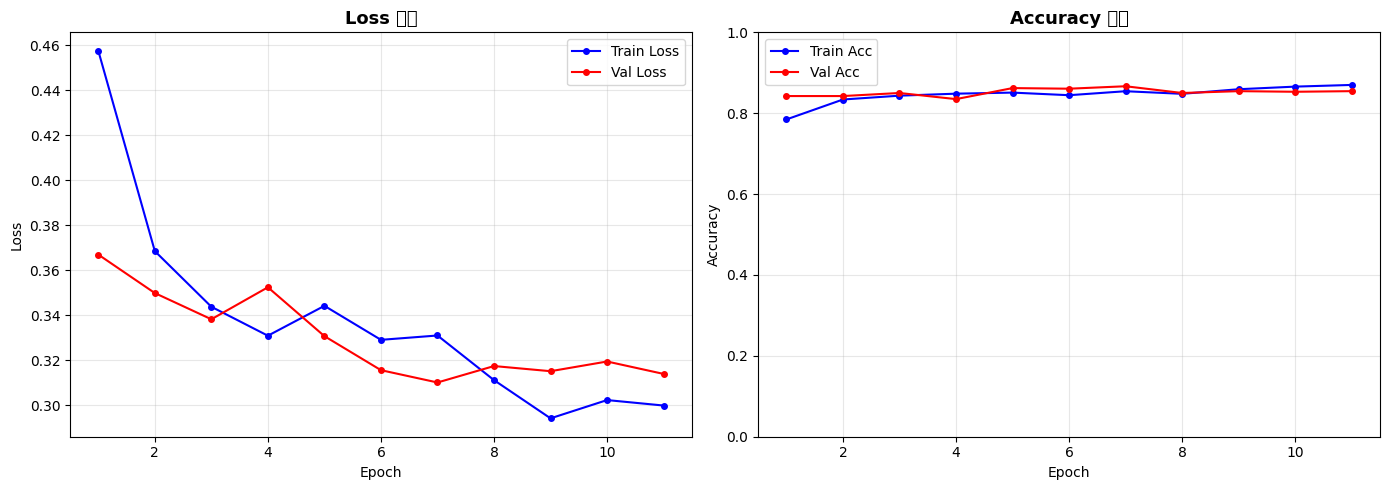

In [19]:
# ✅ Loss & Accuracy 곡선 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs = range(1, len(history["train_loss"]) + 1) # Adjust epochs to actual trained length

# Loss 곡선
axes[0].plot(epochs, history["train_loss"], "b-o", markersize=4, label="Train Loss")
axes[0].plot(epochs, history["val_loss"],   "r-o", markersize=4, label="Val Loss")
axes[0].set_title("Loss 곡선", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy 곡선
axes[1].plot(epochs, history["train_acc"], "b-o", markersize=4, label="Train Acc")
axes[1].plot(epochs, history["val_acc"],   "r-o", markersize=4, label="Val Acc")
axes[1].set_title("Accuracy 곡선", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

파인튜닝

In [20]:
model.load_state_dict(torch.load("best_model_ft.pth"))  # ✅ 파인튜닝 후 모델

# ✅ 전체 레이어 확인
for i, (name, param) in enumerate(model.named_parameters()):
    print(f"[{i:>3}] {name:<60} requires_grad={param.requires_grad}")

[  0] features.0.0.weight                                          requires_grad=False
[  1] features.0.1.weight                                          requires_grad=False
[  2] features.0.1.bias                                            requires_grad=False
[  3] features.1.0.block.0.0.weight                                requires_grad=False
[  4] features.1.0.block.0.1.weight                                requires_grad=False
[  5] features.1.0.block.0.1.bias                                  requires_grad=False
[  6] features.1.0.block.1.fc1.weight                              requires_grad=False
[  7] features.1.0.block.1.fc1.bias                                requires_grad=False
[  8] features.1.0.block.1.fc2.weight                              requires_grad=False
[  9] features.1.0.block.1.fc2.bias                                requires_grad=False
[ 10] features.1.0.block.2.0.weight                                requires_grad=False
[ 11] features.1.0.block.2.1.weight        

In [21]:
# ✅ 뒤쪽 레이어(features[6], [7], [8] + classifier)만 학습 허용
# EfficientNetB0의 features는 0~8까지 존재
for name, param in model.named_parameters():
    if any(f"features.{i}" in name for i in [6, 7, 8]) or "classifier" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"✅ 파인튜닝 레이어 설정 완료")
print(f"   학습 가능한 파라미터: {trainable:,}개 / 전체: {total:,}개")

✅ 파인튜닝 레이어 설정 완료
   학습 가능한 파라미터: 3,319,837개 / 전체: 4,171,645개


In [22]:
# ✅ 파인튜닝용 옵티마이저 & 스케줄러 재정의
# lr을 낮게 설정해야 기존 가중치가 무너지지 않아요
optimizer_ft = torch.optim.Adam([
    {"params": model.features[6].parameters(), "lr": 1e-5},
    {"params": model.features[7].parameters(), "lr": 1e-5},
    {"params": model.features[8].parameters(), "lr": 1e-5},
    {"params": model.classifier.parameters(),  "lr": 1e-4},
])

scheduler_ft = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_ft, T_max=20, eta_min=1e-6
)

print("✅ 파인튜닝 옵티마이저 설정 완료")
print("   features[6,7,8]: lr=1e-5")
print("   classifier     : lr=1e-4")

✅ 파인튜닝 옵티마이저 설정 완료
   features[6,7,8]: lr=1e-5
   classifier     : lr=1e-4


In [23]:
# ✅ 파인튜닝 학습 실행 (30 에폭 추가)
FT_EPOCHS = 30
best_val_acc_ft = 0.0

history_ft = {"train_loss": [], "train_acc": [],
              "val_loss":   [], "val_acc":   []}

print("🚀 파인튜닝 시작!\n")
print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>8}")
print("-" * 55)

for epoch in range(1, FT_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer_ft)
    val_loss,   val_acc   = evaluate(model, test_loader, criterion)
    scheduler_ft.step()

    history_ft["train_loss"].append(train_loss)
    history_ft["train_acc"].append(train_acc)
    history_ft["val_loss"].append(val_loss)
    history_ft["val_acc"].append(val_acc)

    if val_acc > best_val_acc_ft:
        best_val_acc_ft = val_acc
        torch.save(model.state_dict(), "best_model_ft.pth")
        flag = " ⭐ 저장됨"
    else:
        flag = ""

    print(f"{epoch:>5} | {train_loss:>10.4f} | {train_acc:>8.2%} | {val_loss:>8.4f} | {val_acc:>8.2%}{flag}")

print(f"\n✅ 파인튜닝 완료!  최고 Val Accuracy: {best_val_acc_ft:.2%}")

🚀 파인튜닝 시작!

Epoch | Train Loss | Train Acc | Val Loss |  Val Acc
-------------------------------------------------------
    1 |     0.2540 |   89.53% |   0.2914 |   87.12% ⭐ 저장됨
    2 |     0.2323 |   89.42% |   0.2807 |   86.82%
    3 |     0.2364 |   89.50% |   0.2794 |   86.82%
    4 |     0.2306 |   89.80% |   0.2780 |   87.42% ⭐ 저장됨
    5 |     0.2337 |   89.50% |   0.2718 |   88.33% ⭐ 저장됨
    6 |     0.2188 |   90.29% |   0.2812 |   87.58%
    7 |     0.2103 |   91.77% |   0.2786 |   87.88%
    8 |     0.2279 |   90.10% |   0.2742 |   88.18%
    9 |     0.2195 |   90.86% |   0.2710 |   88.48% ⭐ 저장됨
   10 |     0.2152 |   91.13% |   0.2691 |   89.09% ⭐ 저장됨
   11 |     0.2073 |   90.75% |   0.2724 |   88.48%
   12 |     0.2096 |   90.25% |   0.2659 |   88.79%
   13 |     0.2141 |   90.37% |   0.2671 |   88.64%
   14 |     0.2090 |   91.32% |   0.2600 |   88.94%
   15 |     0.2087 |   90.97% |   0.2684 |   88.18%
   16 |     0.2058 |   91.47% |   0.2658 |   88.79%
   17 |     0.197

/tmp/ipykernel_24176/766099840.py:23: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24176/766099840.py:23: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24176/766099840.py:23: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24176/766099840.py:23: UserWarning: Glyph 51316 (\N{HANGUL SYLLABLE JON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24176/766099840.py:23: UserWarning: Glyph 54028 (\N{HANGUL SYLLABLE PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24176/766099840.py:23: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24176/766099840.py:23: UserWarning: Glyph 53916 (\N{HANGUL SYLLABLE TYU}) missing from font(s) DejaVu Sans.
  plt.tight_layou

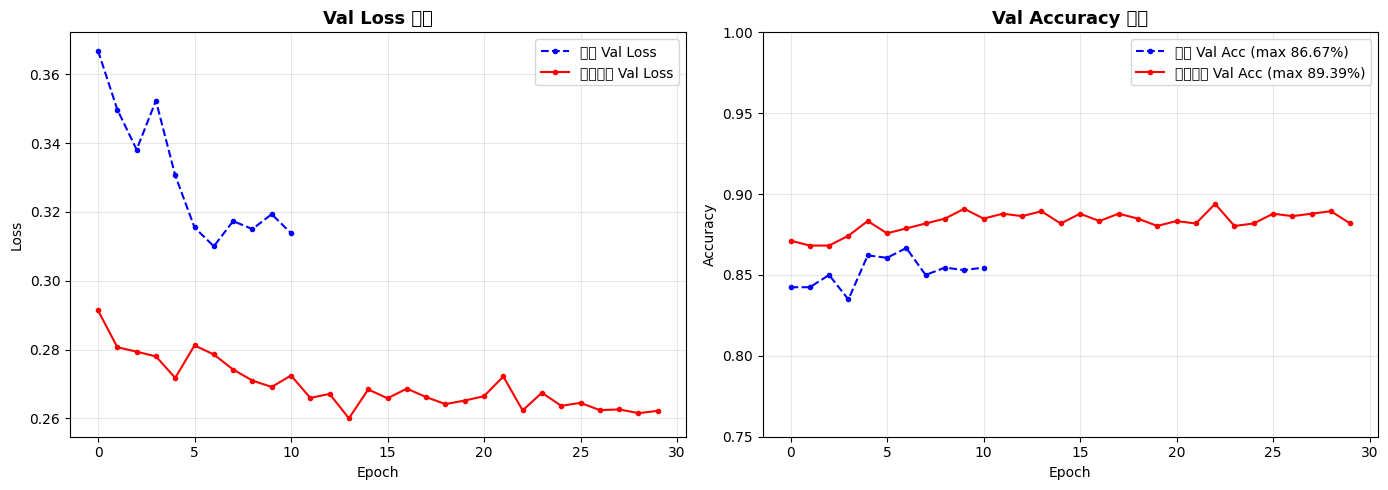

In [24]:
# ✅ 기존 학습 vs 파인튜닝 비교 그래프
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss 비교
axes[0].plot(history["val_loss"],    "b--o", markersize=3, label="기존 Val Loss")
axes[0].plot(history_ft["val_loss"], "r-o",  markersize=3, label="파인튜닝 Val Loss")
axes[0].set_title("Val Loss 비교", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy 비교
axes[1].plot(history["val_acc"],    "b--o", markersize=3, label=f"기존 Val Acc (max {max(history['val_acc']):.2%})")
axes[1].plot(history_ft["val_acc"], "r-o",  markersize=3, label=f"파인튜닝 Val Acc (max {best_val_acc_ft:.2%})")
axes[1].set_title("Val Accuracy 비교", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.75, 1.0)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

최종 평가

In [25]:
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_curve, auc, ConfusionMatrixDisplay)
import numpy as np

# ✅ 최고 성능 모델 불러오기
model.load_state_dict(torch.load("best_model_ft.pth"))
model.eval()

all_labels  = []
all_probs   = []
all_preds   = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs).squeeze(1).cpu().numpy()
        preds = (probs >= 0.5).astype(int)

        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)
all_preds  = np.array(all_preds)

print("✅ 예측 완료")

✅ 예측 완료


/tmp/ipykernel_24176/879220497.py:22: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24176/879220497.py:22: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


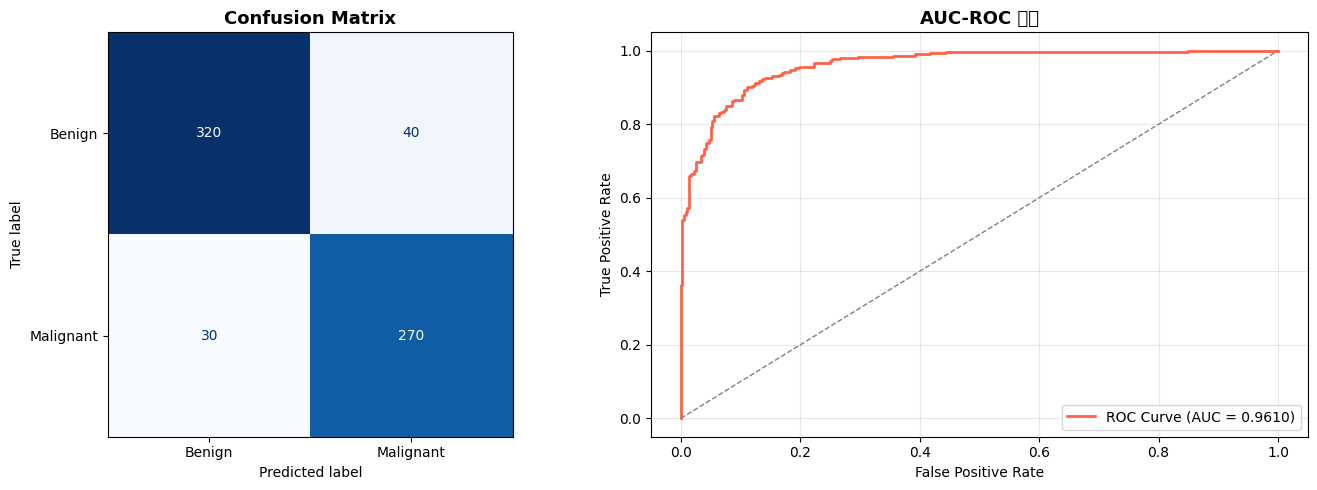

In [26]:
# ✅ Confusion Matrix 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Benign", "Malignant"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix", fontsize=13, fontweight="bold")

# ✅ AUC-ROC 곡선 시각화
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color="tomato", lw=2,
             label=f"ROC Curve (AUC = {roc_auc:.4f})")
axes[1].plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("AUC-ROC 곡선", fontsize=13, fontweight="bold")
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
# ✅ 상세 성능 지표 출력
print("=" * 50)
print("📊 최종 성능 평가 결과")
print("=" * 50)
print(classification_report(all_labels, all_preds,
                             target_names=["Benign", "Malignant"]))
print(f"  AUC-ROC Score : {roc_auc:.4f}")

tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)  # 악성 실제 탐지율
specificity = tn / (tn + fp)  # 양성 실제 탐지율
print(f"  Sensitivity   : {sensitivity:.4f}  (악성을 악성으로 맞춘 비율)")
print(f"  Specificity   : {specificity:.4f}  (양성을 양성으로 맞춘 비율)")
print("=" * 50)

📊 최종 성능 평가 결과
              precision    recall  f1-score   support

      Benign       0.91      0.89      0.90       360
   Malignant       0.87      0.90      0.89       300

    accuracy                           0.89       660
   macro avg       0.89      0.89      0.89       660
weighted avg       0.89      0.89      0.89       660

  AUC-ROC Score : 0.9610
  Sensitivity   : 0.9000  (악성을 악성으로 맞춘 비율)
  Specificity   : 0.8889  (양성을 양성으로 맞춘 비율)


잘못 분류된 이미지 시각화

In [28]:
# ✅ 파인튜닝 최고 모델 불러오기
model.load_state_dict(torch.load("best_model_ft.pth"))
model.eval()

# ✅ 전체 테스트셋 예측 및 오분류 수집
wrong_images, wrong_labels, wrong_preds, wrong_probs = [], [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs).squeeze(1).cpu()
        preds = (probs >= 0.5).long()

        # 오분류 샘플만 추출
        mask = preds != labels
        wrong_images.extend(images[mask].cpu())
        wrong_labels.extend(labels[mask].numpy())
        wrong_preds.extend(preds[mask].numpy())
        wrong_probs.extend(probs[mask].numpy())

print(f"✅ 전체 오분류 샘플 수: {len(wrong_images)}개")
print(f"   - 악성을 양성으로 (FN): {sum(l==1 and p==0 for l,p in zip(wrong_labels, wrong_preds))}개")
print(f"   - 양성을 악성으로 (FP): {sum(l==0 and p==1 for l,p in zip(wrong_labels, wrong_preds))}개")

✅ 전체 오분류 샘플 수: 70개
   - 악성을 양성으로 (FN): 30개
   - 양성을 악성으로 (FP): 40개


/tmp/ipykernel_24176/3198272706.py:45: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24176/3198272706.py:45: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24176/3198272706.py:45: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24176/3198272706.py:45: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24176/3198272706.py:45: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24176/3198272706.py:45: UserWarning: Glyph 50501 (\N{HANGUL SYLLABLE AG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24176/3198272706.py:45: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.ti

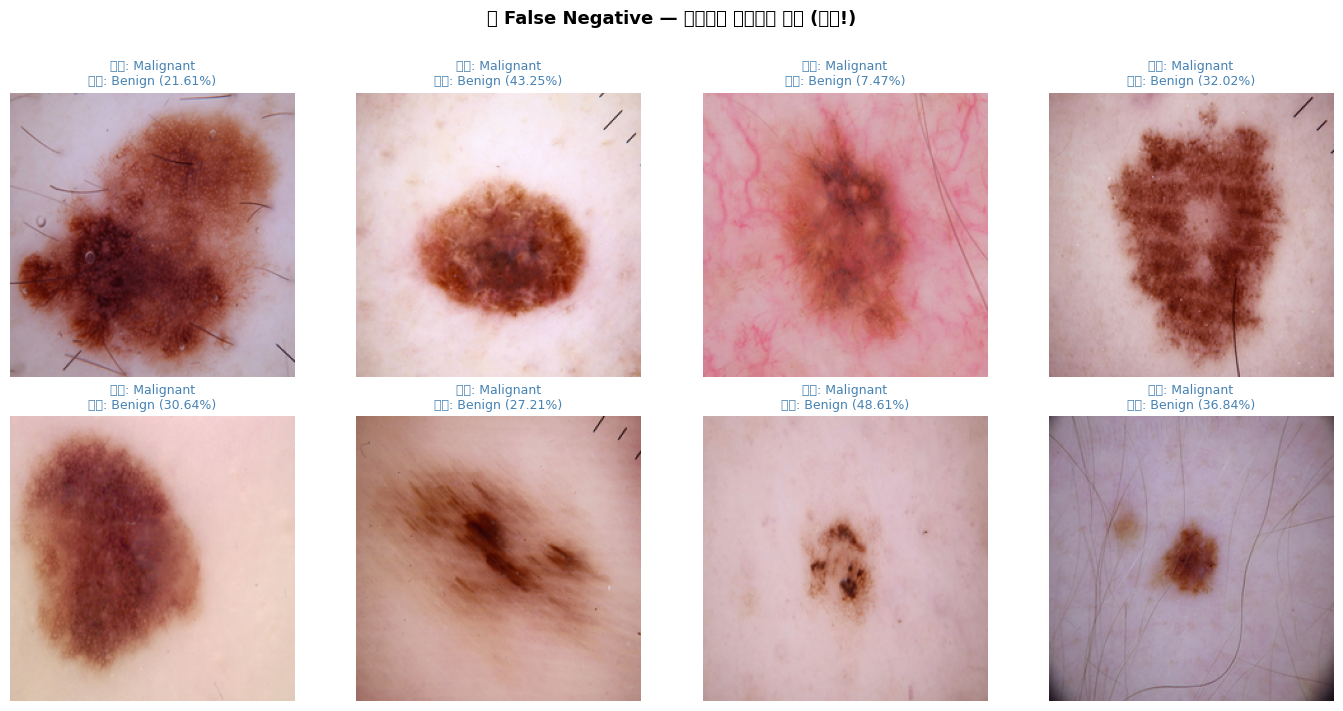

/tmp/ipykernel_24176/3198272706.py:45: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


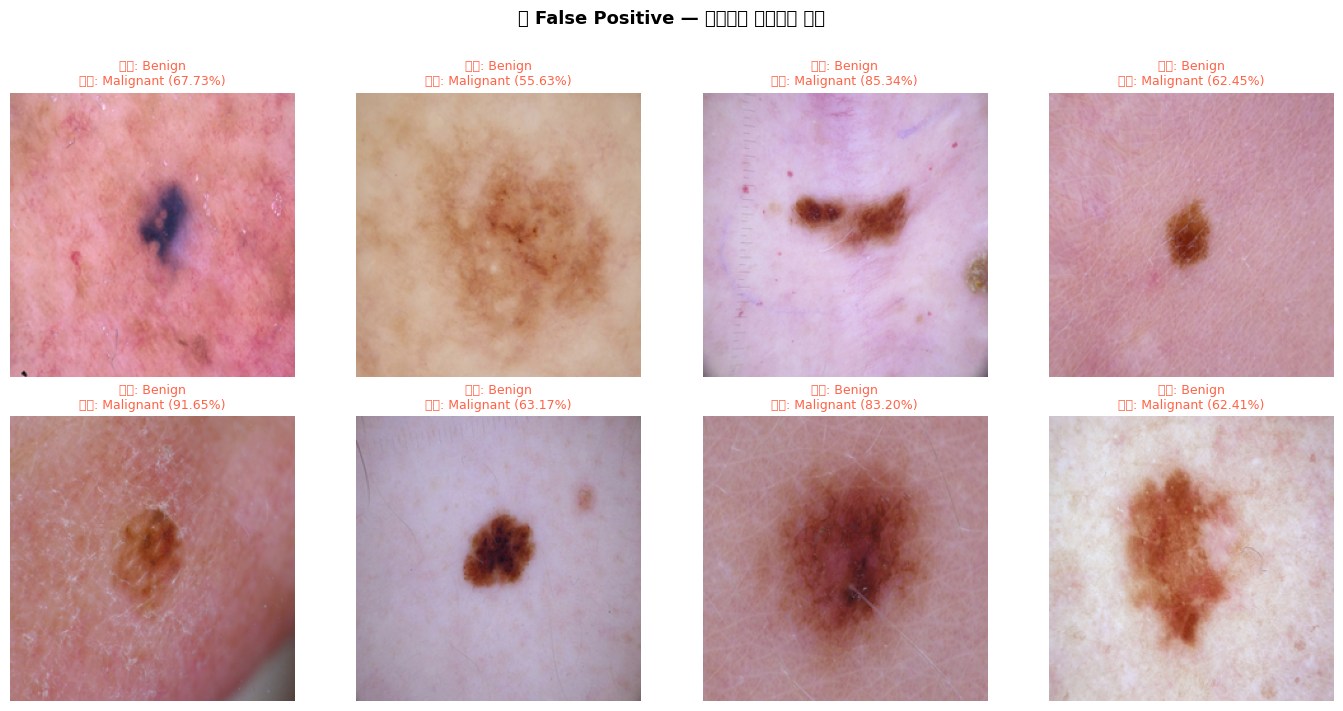

In [29]:
# ✅ 오분류 이미지 시각화 (FN / FP 각 8장씩)
import torchvision.transforms.functional as TF

# ImageNet 정규화 역변환
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

def denormalize(tensor):
    return torch.clamp(tensor * std + mean, 0, 1)

class_names = ["Benign", "Malignant"]
colors      = {"Benign": "steelblue", "Malignant": "tomato"}

for error_type, true_cls, pred_cls, title in [
    ("FN", 1, 0, "🔴 False Negative — 악성인데 양성으로 예측 (위험!)"),
    ("FP", 0, 1, "🟡 False Positive — 양성인데 악성으로 예측"),
]:
    samples = [(img, lb, pd, pr) for img, lb, pd, pr
               in zip(wrong_images, wrong_labels, wrong_preds, wrong_probs)
               if lb == true_cls and pd == pred_cls][:8]

    if not samples:
        print(f"{error_type} 샘플 없음")
        continue

    cols = min(len(samples), 4)
    rows = (len(samples) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.5))
    fig.suptitle(title, fontsize=13, fontweight="bold", y=1.01)
    axes = np.array(axes).flatten()

    for i, (img, lb, pd, pr) in enumerate(samples):
        img_show = denormalize(img).permute(1, 2, 0).numpy()
        axes[i].imshow(img_show)
        axes[i].set_title(
            f"실제: {class_names[lb]}\n예측: {class_names[pd]} ({pr:.2%})",
            fontsize=9,
            color=colors[class_names[pd]]
        )
        axes[i].axis("off")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

In [30]:
# ✅ 1차 학습 vs 파인튜닝 최종 성능 비교표 (최종 평가 섹션 맨 아래에 추가)
print("\n" + "=" * 50)
print("📈 성능 향상 비교")
print("=" * 50)
print(f"  1차 학습  Val Accuracy : {max(history['val_acc']):.2%}")
print(f"  파인튜닝  Val Accuracy : {best_val_acc_ft:.2%}")
print(f"  성능 향상              : +{(best_val_acc_ft - max(history['val_acc']))*100:.2f}%p")
print(f"  최종 AUC-ROC           : {roc_auc:.4f}")
print("=" * 50)


📈 성능 향상 비교
  1차 학습  Val Accuracy : 86.67%
  파인튜닝  Val Accuracy : 89.39%
  성능 향상              : +2.73%p
  최종 AUC-ROC           : 0.9610
